In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, FloatSlider, SelectionSlider

---

In [2]:
files = [
    'data/jacobi_diag_cpu_test_16_double_metrics.csv',
    'data/jacobi_mg_cpu_test_16_double_metrics.csv',
    'data/gmres_diag_cpu_test_16_double_metrics.csv',
    'data/gmres_mg_cpu_test_16_double_metrics.csv',
]

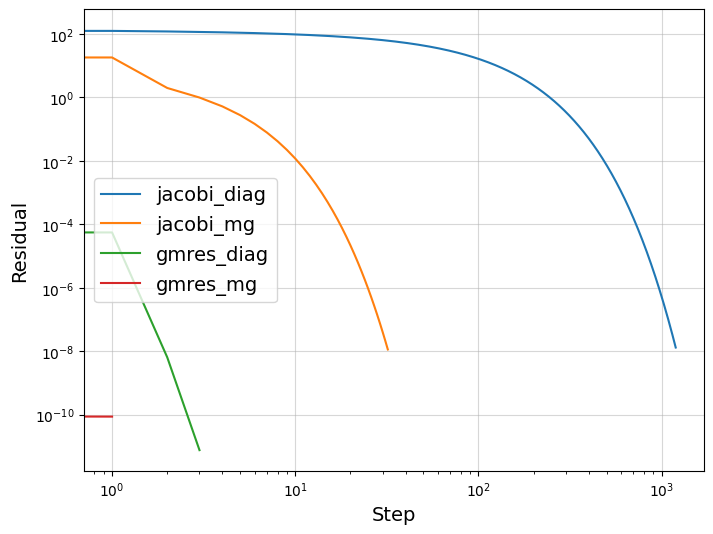

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for file in files:
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    plt.plot(np.arange(len(data[:, 1]), dtype=int), data[:, 1], label='_'.join(file.split('/')[1].split('_')[:2]))

plt.legend(fontsize=14)

plt.xlabel('Step', fontsize=14)
plt.ylabel('Residual', fontsize=14)

plt.xscale('log')
plt.yscale('log')

plt.show()

---

## Problem Solution Visualization

In [15]:
# ============================================================
# Load numerical solution from binary file
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Load numerical and exact solutions
folder = 'random_init_ch_test_20260123_180347'
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in numerical_files:
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

# Load exact solution (always single file)
exact_file = f'{folder_path}/exact.bin'
if os.path.exists(exact_file):
    exact_loaded, _ = load_solution(exact_file)
else:
    exact_loaded = None
    print("Warning: exact.bin not found, exact solution will not be displayed")

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")
if exact_loaded is not None:
    print(f"Exact solution shape: {exact_loaded.shape}")

Loaded solutions with grid size N = 64
Number of frames: 11 (index 0 = initial approximation, 1-10 = after time steps)
Solution shape: (11, 64, 64, 64, 2)
Components: [psi, phi]


In [ ]:
# ============================================================
# 1D Visualization: exact (loaded) + numerical (scatter) with time slider
# ============================================================
from ipywidgets import interact, FloatSlider, Dropdown, SelectionSlider, IntSlider

# Precompute global min/max for fixed y-axis limits (±10% margin) across all frames
y_limits = {}
for comp in [0, 1]:
    ymin = numerical[:,:,:,:,comp].min()
    ymax = numerical[:,:,:,:,comp].max()
    margin = 0.1 * (ymax - ymin) if ymax != ymin else 0.1
    y_limits[comp] = (ymin - margin, ymax + margin)

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = [h * (0.5 + i) for i in range(N)]

def plot_1d(frame_idx=0, vary_axis=0, fixed_val_1=0.5, fixed_val_2=0.5, component=1):
    """
    1D plot: exact solution (loaded) and numerical as scatter points.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    vary_axis: 0=x, 1=y, 2=z (coordinate that varies along the line)
    fixed_val_1, fixed_val_2: cell-centered coordinate values for the two fixed coordinates
    component: 0=psi, 1=phi
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    fixed_axes = [i for i in range(3) if i != vary_axis]

    # Get numerical solution for the selected frame
    # numerical shape is always (num_frames, N, N, N, 2) after preprocessing
    numerical_frame = numerical[frame_idx]

    # Coordinate values for plotting
    t_num = np.array(cell_centered_coords)

    # Find indices corresponding to fixed coordinate values
    idx_1 = cell_centered_coords.index(fixed_val_1)
    idx_2 = cell_centered_coords.index(fixed_val_2)

    # Extract values along the varying axis
    if vary_axis == 0:
        num_vals = numerical_frame[:, idx_1, idx_2, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[:, idx_1, idx_2, component]
    elif vary_axis == 1:
        num_vals = numerical_frame[idx_1, :, idx_2, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[idx_1, :, idx_2, component]
    else:
        num_vals = numerical_frame[idx_1, idx_2, :, component]
        if exact_loaded is not None:
            exact_vals = exact_loaded[idx_1, idx_2, :, component]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    if exact_loaded is not None:
        ax.plot(t_num, exact_vals, 'b-', lw=2, marker='o', markersize=4, label='Exact')

    ax.scatter(t_num, num_vals, c='red', s=60, zorder=5, label='Numerical', edgecolors='black')

    # Fixed y-axis limits (global min/max ±10%)
    ax.set_ylim(y_limits[component])

    ax.set_xlabel(axis_names[vary_axis], fontsize=14)
    ax.set_ylabel(component_names[component], fontsize=14)

    title = f'Cahn-hilliard: {component_names[component]} along {axis_names[vary_axis]}, '
    title += f'{axis_names[fixed_axes[0]]}={fixed_val_1:.4f}, '
    title += f'{axis_names[fixed_axes[1]]}={fixed_val_2:.4f}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=12)

    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

interact(
    plot_1d,
    frame_idx=frame_slider,
    vary_axis=Dropdown(options=[('x (fix y,z)', 0), ('y (fix x,z)', 1), ('z (fix x,y)', 2)], value=0, description='Axis:'),
    fixed_val_1=SelectionSlider(options=[(f'{coord:.4f}', coord) for coord in cell_centered_coords], value=cell_centered_coords[N//2], description='Fixed 1:'),
    fixed_val_2=SelectionSlider(options=[(f'{coord:.4f}', coord) for coord in cell_centered_coords], value=cell_centered_coords[N//2], description='Fixed 2:'),
    component=Dropdown(options=[('ψ (psi)', 0), ('φ (phi)', 1)], value=1, description='Field:')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Frame:', max=10), Dropdown(description='Axis:', options=…

---

In [ ]:
# ============================================================
# 2D Heatmap Visualization for Perlin Noise Solution
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Update this folder name to match your Perlin noise run
folder = 'random_init_ch_test_20260123_184122'  # Change this to your actual folder name
folder_path = f'data/{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in numerical_files:
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

# Precompute global min/max for consistent colorbar scaling across all frames
vmin_global = {}
vmax_global = {}
for comp in [0, 1]:
    vmin_global[comp] = numerical[:,:,:,:,comp].min()
    vmax_global[comp] = numerical[:,:,:,:,comp].max()

def plot_2d_heatmap(frame_idx=0, slice_axis=2, layer_idx=16, component=1):
    """
    2D heatmap visualization of solution slice.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    slice_axis: 0=x, 1=y, 2=z (axis perpendicular to the slice plane)
    layer_idx: index of the layer along slice_axis (0 to N-1)
    component: 0=psi, 1=phi
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    # Get numerical solution for the selected frame
    numerical_frame = numerical[frame_idx]

    # Extract 2D slice based on slice_axis and layer_idx
    if slice_axis == 0:  # Slice along x-axis: show y-z plane
        slice_data = numerical_frame[layer_idx, :, :, component]
        x_coords = cell_centered_coords  # y coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'y'
        ylabel = 'z'
        title_axis = f'x = {cell_centered_coords[layer_idx]:.4f}'
    elif slice_axis == 1:  # Slice along y-axis: show x-z plane
        slice_data = numerical_frame[:, layer_idx, :, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'x'
        ylabel = 'z'
        title_axis = f'y = {cell_centered_coords[layer_idx]:.4f}'
    else:  # slice_axis == 2, Slice along z-axis: show x-y plane
        slice_data = numerical_frame[:, :, layer_idx, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # y coordinates
        xlabel = 'x'
        ylabel = 'y'
        title_axis = f'z = {cell_centered_coords[layer_idx]:.4f}'

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Create heatmap
    im = ax.pcolormesh(X, Y, slice_data,
                       cmap='viridis',
                    #    vmin=vmin_global[component],
                    #    vmax=vmax_global[component],
                       shading='gouraud')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(component_names[component], fontsize=14)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Title
    title = f'Cahn-Hilliard: {component_names[component]} slice at {title_axis}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=14)

    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

# Create layer slider
layer_slider = IntSlider(min=0, max=N-1, value=N//2, description='Layer:')

interact(
    plot_2d_heatmap,
    frame_idx=frame_slider,
    slice_axis=Dropdown(
        options=[('x (show y-z plane)', 0), ('y (show x-z plane)', 1), ('z (show x-y plane)', 2)],
        value=2,
        description='Slice axis:'
    ),
    layer_idx=layer_slider,
    component=Dropdown(
        options=[('ψ (psi)', 0), ('φ (phi)', 1)],
        value=1,
        description='Field:'
    )
)
plt.show()

Loaded solutions with grid size N = 64
Number of frames: 101 (index 0 = initial approximation, 1-100 = after time steps)
Solution shape: (101, 64, 64, 64, 2)
Components: [psi, phi]


interactive(children=(IntSlider(value=0, description='Frame:'), Dropdown(description='Slice axis:', index=2, o…